In [165]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/spaceship-titanic/sample_submission.csv
/kaggle/input/competitions/spaceship-titanic/train.csv
/kaggle/input/competitions/spaceship-titanic/test.csv


#  Spaceship Titanic: Feature Engineering Over Hyperparameter Tuning

## Introduction

The goal of this project was to predict whether a passenger aboard the Spaceship Titanic was transported to an alternate dimension.

Rather than focusing immediately on complex models or extensive hyperparameter tuning, this notebook explores how far thoughtful feature engineering and systematic experimentation can improve performance on tabular data.

The final solution achieved a **Public Leaderboard Score of 0.80780**, placing approximately **497th out of 2500+ participants (Top ~20%)**, using a single CatBoost model without ensembles, stacking, or neural networks.

---

# Problem Statement

Given passenger information such as:

- HomePlanet
- Destination
- Cabin
- Spending behavior
- CryoSleep status
- VIP status

Predict whether the passenger was transported (`Transported = True`) or not.

---

# Basic EDA

In [166]:
df=pd.read_csv("/kaggle/input/competitions/spaceship-titanic/train.csv")
df_test=pd.read_csv("/kaggle/input/competitions/spaceship-titanic/test.csv")

## Basic Statistics and Information about the dataset

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [168]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [169]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [170]:
df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [171]:
df_test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

### Checking if dataset is imbalanced or not

In [172]:
df["Transported"].value_counts()


Transported
True     4378
False    4315
Name: count, dtype: int64

In [173]:
num_cols=df.select_dtypes(include=[np.number])
cat_cols=df.select_dtypes(exclude=[np.number])

In [174]:
for col in cat_cols:
    print(
        pd.crosstab(
            df[col],
            df["Transported"],
            normalize="index"
        ) * 100
    )

Transported  False  True 
PassengerId              
0001_01      100.0    0.0
0002_01        0.0  100.0
0003_01      100.0    0.0
0003_02      100.0    0.0
0004_01        0.0  100.0
...            ...    ...
9276_01      100.0    0.0
9278_01      100.0    0.0
9279_01        0.0  100.0
9280_01      100.0    0.0
9280_02        0.0  100.0

[8693 rows x 2 columns]
Transported      False      True 
HomePlanet                       
Earth        57.605389  42.394611
Europa       34.115439  65.884561
Mars         47.697555  52.302445
Transported      False      True 
CryoSleep                        
False        67.107924  32.892076
True         18.241686  81.758314
Transported  False  True 
Cabin                    
A/0/P         50.0   50.0
A/0/S        100.0    0.0
A/1/S          0.0  100.0
A/10/P       100.0    0.0
A/10/S         0.0  100.0
...            ...    ...
T/0/P        100.0    0.0
T/1/P        100.0    0.0
T/2/P        100.0    0.0
T/2/S        100.0    0.0
T/3/P          0.0 

In [175]:
import matplotlib.pyplot as plt 
import seaborn as sns

# Plotting all numerical features to check distribution, outliers and class distribution

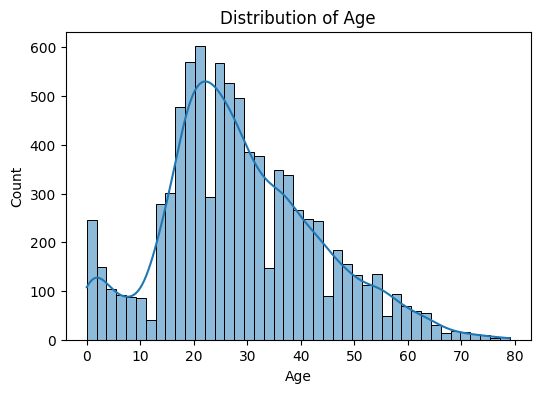

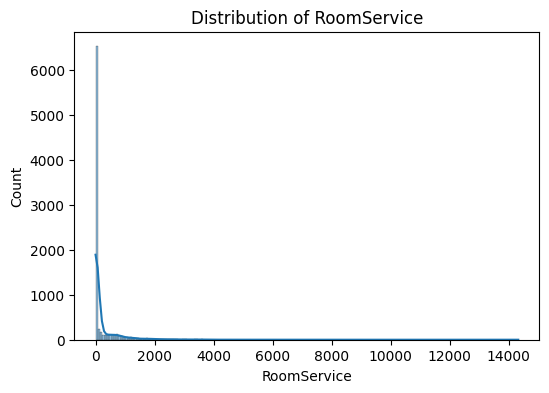

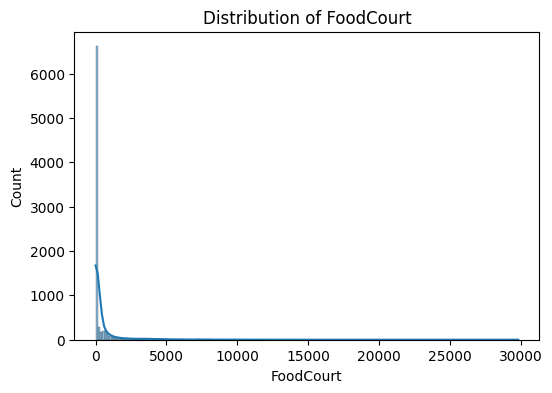

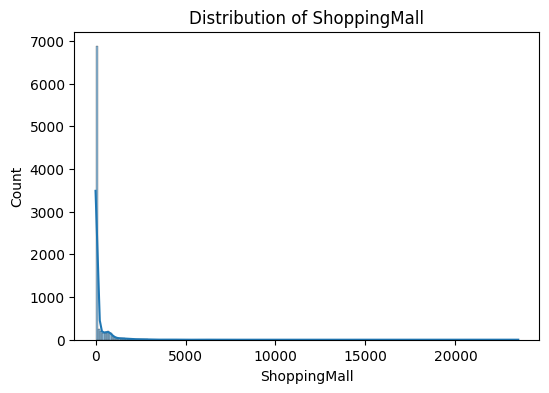

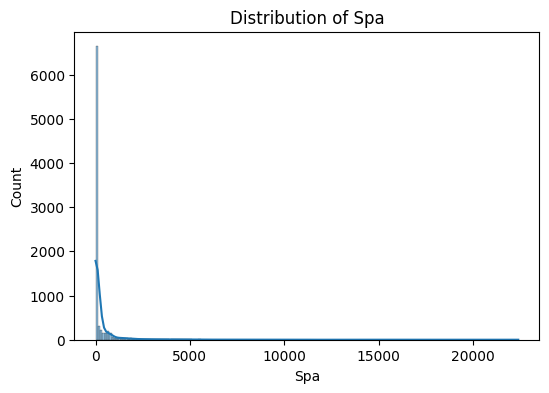

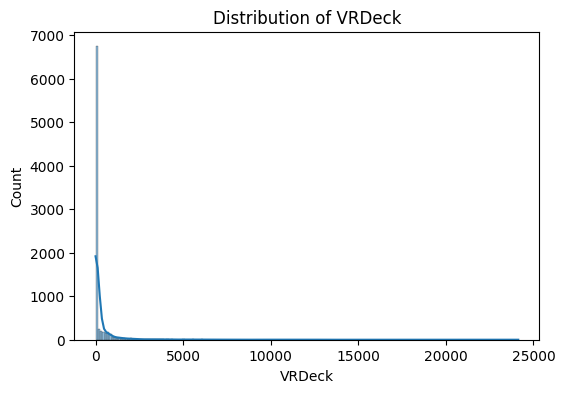

In [176]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


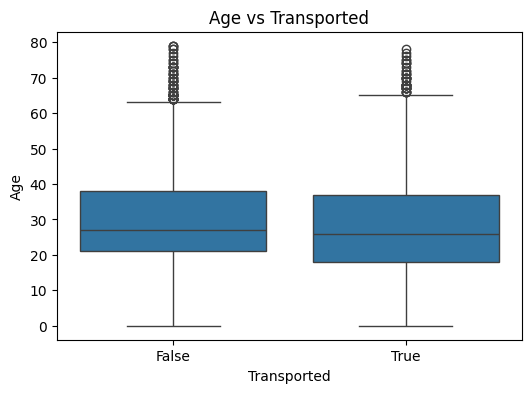

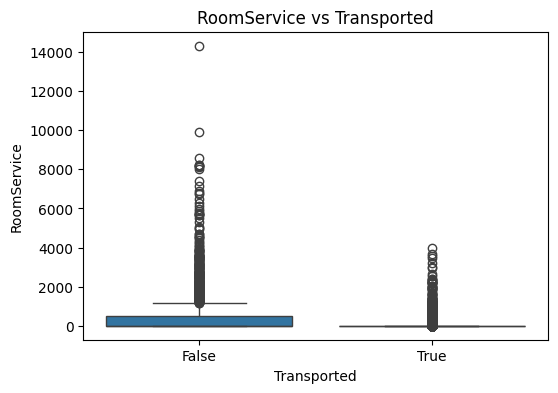

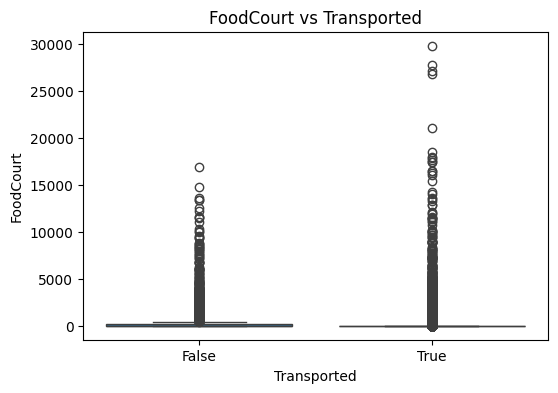

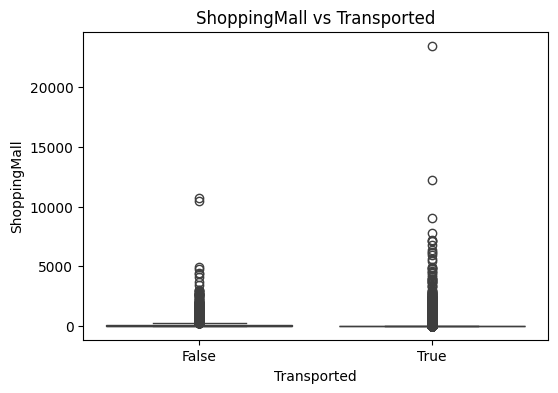

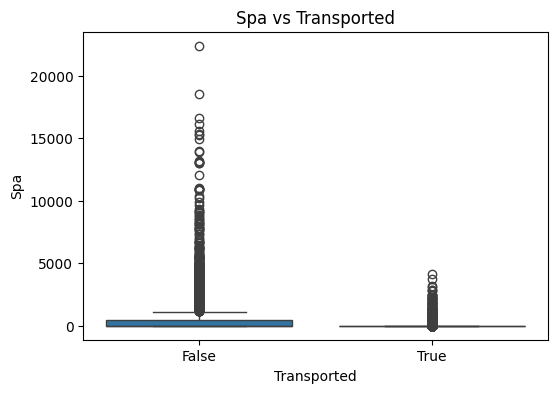

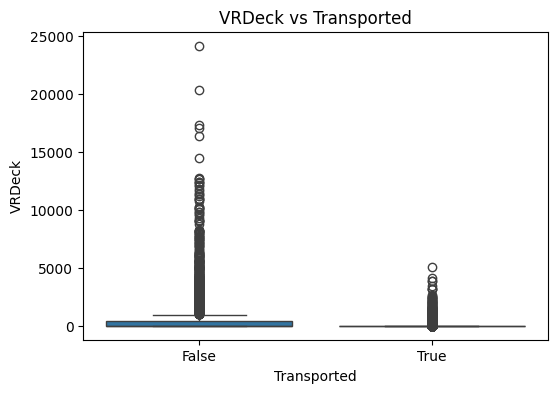

In [177]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        x="Transported",
        y=col,
        data=df
    )
    plt.title(f"{col} vs Transported")
    plt.show()

## Since many collums were highly skewed we plotted log transformed plots and boxplots

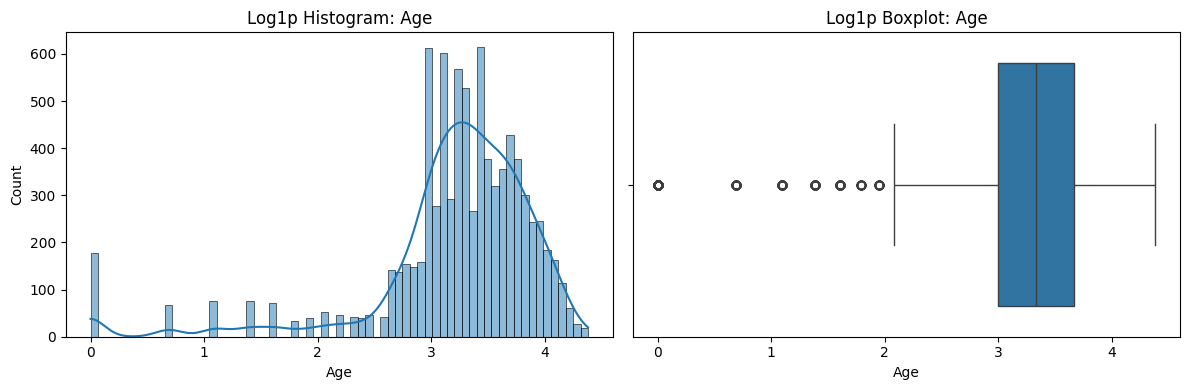

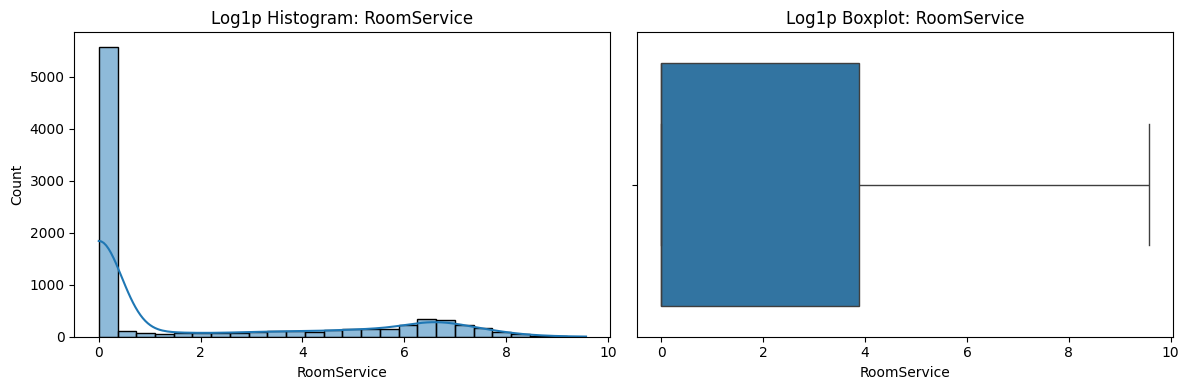

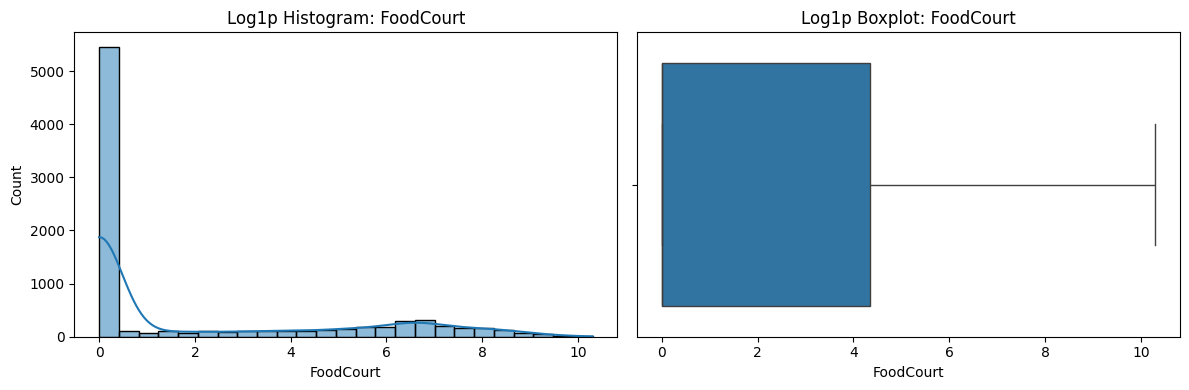

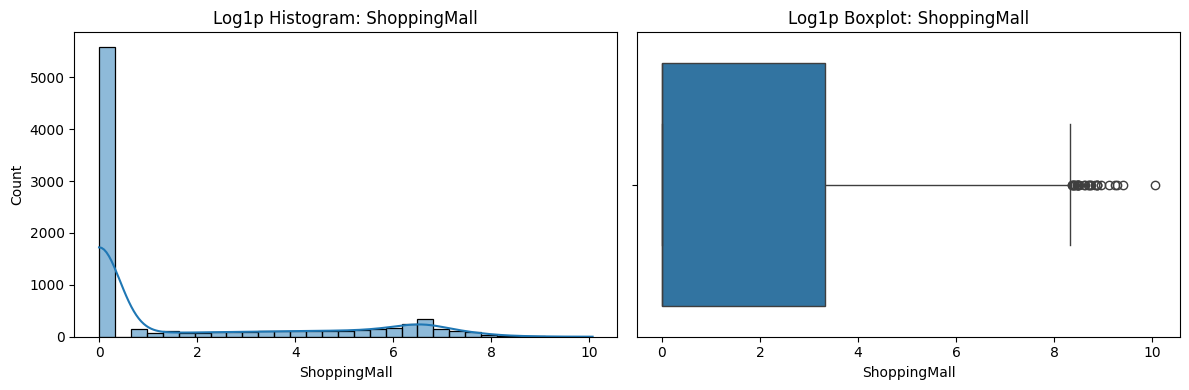

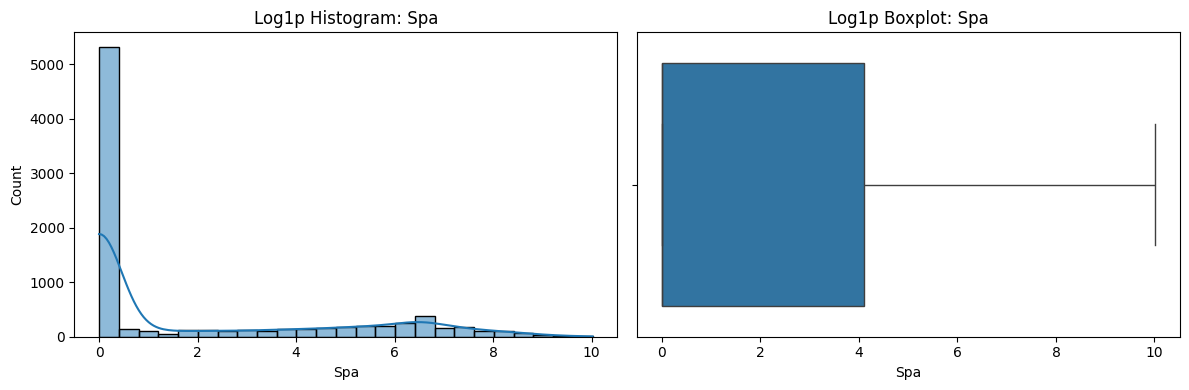

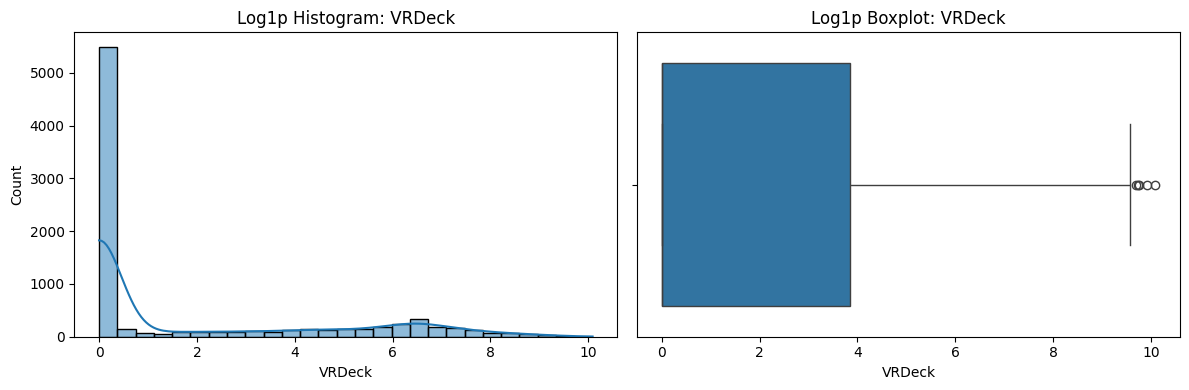

In [178]:

for col in num_cols:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(
        np.log1p(df[col].dropna()),
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f'Log1p Histogram: {col}')

    # Boxplot
    sns.boxplot(
        x=np.log1p(df[col].dropna()),
        ax=axes[1]
    )
    axes[1].set_title(f'Log1p Boxplot: {col}')

    plt.tight_layout()
    plt.show()

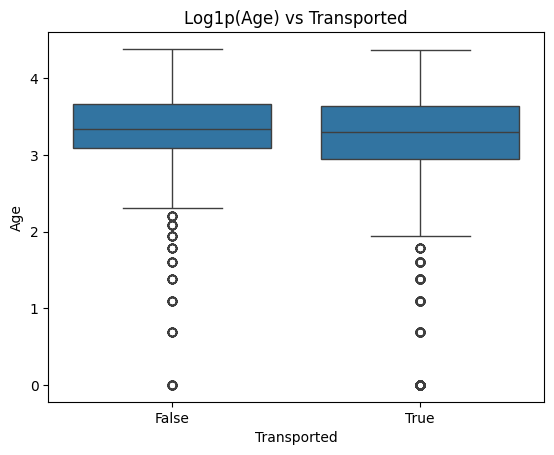

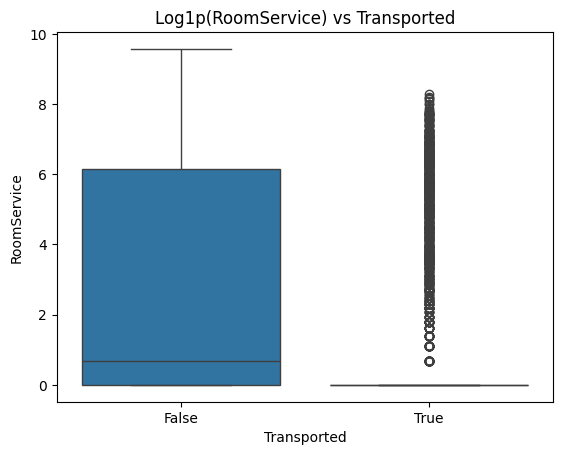

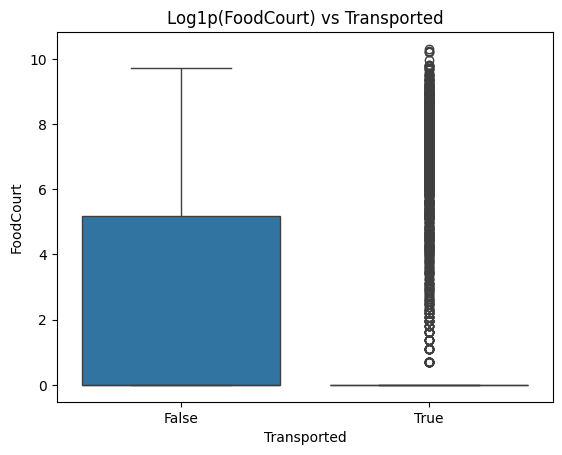

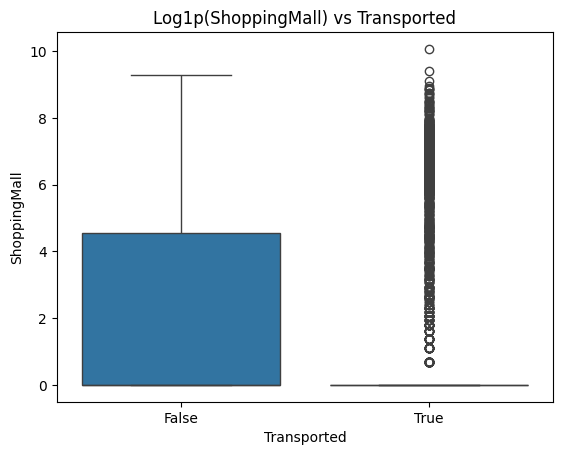

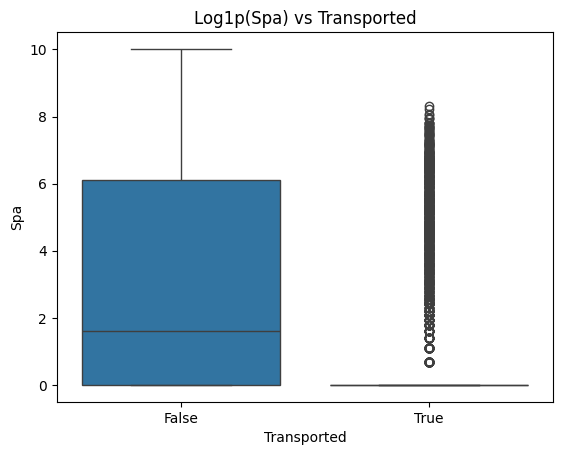

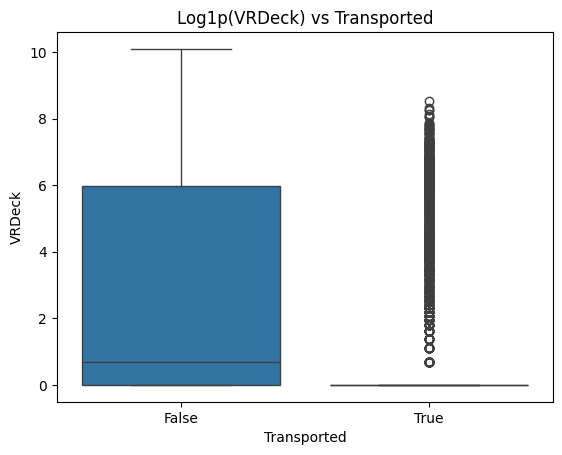

In [179]:
for col in num_cols:

    temp = df.copy()

    sns.boxplot(
        x='Transported',
        y=np.log1p(temp[col]),
        data=temp
    )

    plt.title(f'Log1p({col}) vs Transported')
    plt.show()

# Initial Hypothesis

Before building models, several assumptions were made:

### Hypothesis 1: Spending Behavior Matters

Passengers spending heavily on luxury services may behave differently from passengers spending little or nothing.

Expected useful features:

- TotalSpend
- LuxurySpend
- ZeroSpend
- LogTotalSpend

---

### Hypothesis 2: Cabin Location Contains Signal

The cabin information appears highly structured:

```
Deck/CabinNumber/Side
```

Passengers located near each other may share similar outcomes.

Expected useful features:

- Deck
- CabinNum
- Side
- DeckSide
- CabinNumBucket

---

### Hypothesis 3: Group Travel Matters

Passengers traveling together may experience similar outcomes.

Expected useful features:

- GroupID
- GroupSize
- IsAlone

---

### Hypothesis 4: Missing Values May Be Informative

Missing information is often not random.

Instead of simply imputing values, the model may benefit from knowing which fields were originally missing.

Expected useful features:

- AgeMissing
- CryoSleepMissing
- VIPMissing
- HomePlanetMissing
- DestinationMissing
- CabinMissing

---

# Correlation of Numerical Features with each other to find any instance of multicollinearity or some hidden relation within the columns

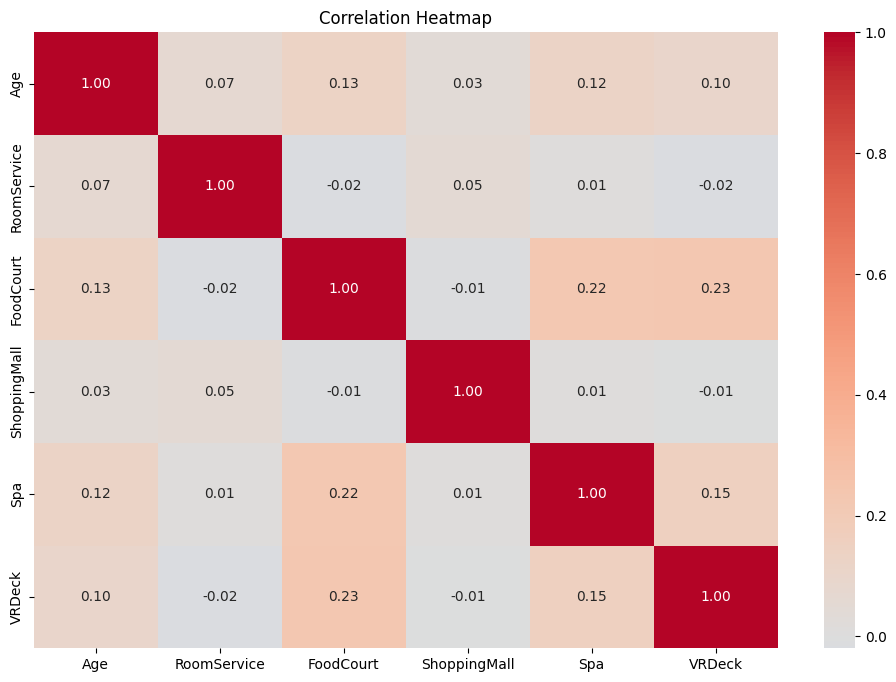

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12,8))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

# Splitting before imputation and feature engineering to protect from overfitting

In [181]:
from sklearn.model_selection import train_test_split

X = df.drop('Transported', axis=1)
y = df['Transported']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_val.shape)

(6954, 13)
(1739, 13)


In [182]:
print(y.mean())
print(y_train.mean())
print(y_val.mean())

0.5036236051995858
0.5035950532067874
0.503737780333525


In [183]:
from sklearn.impute import SimpleImputer


In [184]:
num_cols = X_train.select_dtypes(include=['number']).columns

cat_cols = X_train.columns.difference(num_cols)

# Feature Engineering

## Cabin Features

The Cabin column was decomposed into:

```python
Deck
CabinNum
Side
```

Additional engineered features:

```python
DeckSide = Deck + "_" + Side
CabinNumBucket = CabinNum // 100
```

### Motivation

Cabin numbers likely represent physical proximity.

Bucketing cabin numbers may help the model identify larger location-based patterns while reducing noise.

---

## Group Features

Passenger groups were extracted from PassengerId.

Example:

```text
0001_01
0001_02
0001_03
```

All belong to the same group.

Engineered features:

```python
GroupID
GroupSize
IsAlone
```

### Motivation

Families and travel groups may experience similar transportation outcomes.

---

## Spending Features

Using:

```python
RoomService
FoodCourt
ShoppingMall
Spa
VRDeck
```

Created:

```python
TotalSpend
ZeroSpend
LogTotalSpend
```

### Motivation

Overall spending behavior may reveal socioeconomic or behavioral patterns.

---

## Missing Indicators

Created binary indicators before imputation:

```python
AgeMissing
CryoSleepMissing
VIPMissing
HomePlanetMissing
DestinationMissing
CabinMissing
```

### Motivation

Missing values may themselves carry information. This decision was taken after trying various models without these features. But it was observed that these feature though having least importance heavily improved the scores.

---

In [185]:
def engineer_features(df):

    df = df.copy()

    # Missing indicators FIRST

    df['AgeMissing'] = df['Age'].isna().astype(int)

    df['CryoSleepMissing'] = (
        df['CryoSleep'].isna().astype(int)
    )

    df['VIPMissing'] = (
        df['VIP'].isna().astype(int)
    )

    df['HomePlanetMissing'] = (
        df['HomePlanet'].isna().astype(int)
    )

    df['DestinationMissing'] = (
        df['Destination'].isna().astype(int)
    )

    df['CabinMissing'] = (
        df['Cabin'].isna().astype(int)
    )

    # your existing feature engineering below

    df[['Deck', 'CabinNum', 'Side']] = (
        df['Cabin']
        .str.split('/', expand=True)
    )

    df['CabinNum'] = pd.to_numeric(
        df['CabinNum'],
        errors='coerce'
    )

    df['DeckSide'] = (
        df['Deck'].astype(str)
        + '_'
        + df['Side'].astype(str)
    )

    df['CabinNumBucket'] = (
        df['CabinNum'] // 100
    )

    df['GroupID'] = (
        df['PassengerId']
        .str.split('_')
        .str[0]
    )

    group_sizes = df['GroupID'].value_counts()

    df['GroupSize'] = (
        df['GroupID']
        .map(group_sizes)
    )

    df['IsAlone'] = (
        df['GroupSize'] == 1
    ).astype(int)

    df['TotalSpend'] = (
        df['RoomService']
        + df['FoodCourt']
        + df['ShoppingMall']
        + df['Spa']
        + df['VRDeck']
    )

    df['ZeroSpend'] = (
        df['TotalSpend'] == 0
    ).astype(int)

    df['LogTotalSpend'] = (
        np.log1p(df['TotalSpend'])
    )

    return df

In [186]:
X_train = engineer_features(X_train)
X_val = engineer_features(X_val)
df_test = engineer_features(df_test)

In [187]:
num_cols = X_train.select_dtypes(include=['number']).columns

cat_cols = X_train.columns.difference(num_cols)

In [188]:
num_imputer = SimpleImputer(strategy='median')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols] = num_imputer.transform(X_val[num_cols])
df_test[num_cols] = num_imputer.transform(df_test[num_cols])

In [189]:
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])
df_test[cat_cols] = cat_imputer.transform(df_test[cat_cols])

In [190]:
print(X_train.isnull().sum().sum())
print(X_val.isnull().sum().sum())
print(df_test.isnull().sum().sum())

0
0
0


In [191]:
print(num_cols)
print(cat_cols)

Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'AgeMissing', 'CryoSleepMissing', 'VIPMissing', 'HomePlanetMissing',
       'DestinationMissing', 'CabinMissing', 'CabinNum', 'CabinNumBucket',
       'GroupSize', 'IsAlone', 'TotalSpend', 'ZeroSpend', 'LogTotalSpend'],
      dtype='object')
Index(['Cabin', 'CryoSleep', 'Deck', 'DeckSide', 'Destination', 'GroupID',
       'HomePlanet', 'Name', 'PassengerId', 'Side', 'VIP'],
      dtype='object')


In [192]:
spend_cols = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

In [193]:
import numpy as np

for col in spend_cols:
    X_train[col] = np.log1p(X_train[col])
    X_val[col] = np.log1p(X_val[col])
    df_test[col] = np.log1p(df_test[col])

In [194]:
X_train.shape

(6954, 30)

In [195]:
X_val.shape

(1739, 30)

In [196]:
df_test.shape

(4277, 30)

In [197]:
X_train.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'AgeMissing', 'CryoSleepMissing', 'VIPMissing',
       'HomePlanetMissing', 'DestinationMissing', 'CabinMissing', 'Deck',
       'CabinNum', 'Side', 'DeckSide', 'CabinNumBucket', 'GroupID',
       'GroupSize', 'IsAlone', 'TotalSpend', 'ZeroSpend', 'LogTotalSpend'],
      dtype='object')

# Dropping redundant features
Many features like Cabin , PassengerID, Name, IsAlone, VIP were removed since they were redundant or contributing least to our model.

In [198]:
X_train = X_train.drop(columns=['Cabin'])
X_val = X_val.drop(columns=['Cabin'])
df_test = df_test.drop(columns=['Cabin'])

In [199]:
test_passenger_ids = df_test['PassengerId'].copy()

In [200]:
X_train = X_train.drop(columns=['PassengerId'])
X_val = X_val.drop(columns=['PassengerId'])
df_test = df_test.drop(columns=['PassengerId'])

In [201]:
X_train = X_train.drop(columns=['Name'])
X_val = X_val.drop(columns=['Name'])
df_test = df_test.drop(columns=['Name'])

In [202]:
X_train = X_train.drop(columns=['CabinNum'])
X_val = X_val.drop(columns=['CabinNum'])
df_test = df_test.drop(columns=['CabinNum'])

In [203]:
X_train = X_train.drop(columns=['IsAlone'])
X_val = X_val.drop(columns=['IsAlone'])
df_test = df_test.drop(columns=['IsAlone'])

In [204]:
X_train = X_train.drop(columns=['VIP'])
X_val = X_val.drop(columns=['VIP'])
df_test = df_test.drop(columns=['VIP'])

# Model Choice

## Why CatBoost?

CatBoost was chosen because:

- Handles categorical variables directly
- Performs extremely well on tabular datasets
- Requires minimal preprocessing
- Automatically captures feature interactions
- Handles nonlinear relationships effectively

No one-hot encoding was required.

---




In [205]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

cat_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

model = CatBoostClassifier(
    depth=6,
    learning_rate=0.03,
    iterations=1000,
    l2_leaf_reg=3,

    loss_function='Logloss',
    eval_metric='Accuracy',

    task_type='GPU',
    devices='0',

    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 0.7505033	total: 69.1ms	remaining: 1m 9s
100:	learn: 0.8120506	total: 3.83s	remaining: 34.1s
200:	learn: 0.8212540	total: 7.55s	remaining: 30s
300:	learn: 0.8262870	total: 11.2s	remaining: 26s
400:	learn: 0.8340523	total: 14.9s	remaining: 22.3s
500:	learn: 0.8393730	total: 18.6s	remaining: 18.6s
600:	learn: 0.8452689	total: 22.4s	remaining: 14.9s
700:	learn: 0.8469945	total: 26.1s	remaining: 11.1s
800:	learn: 0.8510210	total: 29.8s	remaining: 7.41s
900:	learn: 0.8537532	total: 33.4s	remaining: 3.67s
999:	learn: 0.8557665	total: 37.1s	remaining: 0us


CatBoostClassifier(depth=6, devices='0', eval_metric='Accuracy', iterations=1000, l2_leaf_reg=3, learning_rate=0.03, loss_function='Logloss', random_seed=42, task_type='GPU', verbose=100)

In [206]:
y_pred = model.predict(X_val)

print(
    "Validation Accuracy:",
    accuracy_score(y_val, y_pred)
)

Validation Accuracy: 0.8125359401955147


In [207]:
# Predict
test_preds = model.predict(df_test)

# Create submission
submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Transported": test_preds.astype(bool)
})

# Save
submission.to_csv("submission.csv", index=False)

print(submission.head())
print("submission.csv saved successfully!")

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01        False
submission.csv saved successfully!


# Critical Pipeline Discovery

## Original Pipeline

```text
Imputation
↓
Feature Engineering
↓
Model
```

Leaderboard Score:

```text
~0.804
```

---

## Revised Pipeline

```text
Feature Engineering
↓
Imputation
↓
Model
```

Leaderboard Score:

```text
0.80593
```

### Observation

A simple reordering of preprocessing steps produced one of the largest improvements of the competition.

Interestingly, the missing indicators themselves later showed near-zero importance.

This suggests that:

> Feature importance alone does not fully explain model performance.

---

# Experiment Log

## Experiment 1: Add DeckSide and CabinNumBucket

### Hypothesis

Passengers located in similar regions of the ship may share outcomes.

Added:

```python
DeckSide
CabinNumBucket
```

### Result

| Score |
|---------|
| 0.80360 |

### Conclusion

Performance decreased slightly.

The hypothesis appeared reasonable, but benefits were not immediately visible.

---

## Experiment 2: Remove LuxurySpend and BasicSpend

### Hypothesis

These features may be redundant because TotalSpend already captures most of the information.

Removed:

```python
LuxurySpend
BasicSpend
```

### Result

| Score |
|---------|
| 0.80453 |

### Conclusion

Performance improved.

This reinforced an important principle:

> More features do not necessarily mean better models.

---

## Experiment 3: HomePlanet_Deck Interaction

Created:

```python
HomePlanet + "_" + Deck
```

### Hypothesis

Different planets may occupy different areas of the ship.

### Result

| Score |
|---------|
| 0.80313 |

### Conclusion

Despite receiving high feature importance, leaderboard performance decreased.

Important lesson:

> High feature importance does not imply genuine predictive value.

---

## Experiment 4: Remove VIP and IsAlone

Feature importance showed:

| Feature | Importance |
|----------|-----------:|
| VIP | ~0.04 |
| IsAlone | ~0.04 |

### Hypothesis

These features may be adding noise.

Removed:

```python
VIP
IsAlone
```

### Result

| Before | After |
|---------|---------|
| 0.80593 | 0.80780 |

### Conclusion

This became the best model of the competition.

---

## Experiment 5: SpendPerPerson

Created:

```python
SpendPerPerson = TotalSpend / GroupSize
```

### Hypothesis

Spending relative to group size may provide stronger signal.

### Result

| Score |
|---------|
| 0.80430 |

### Conclusion

Competitive but failed to beat the best submission.

---

## Experiment 6: Route Feature

Created:

```python
Route = HomePlanet + "_" + Destination
```

### Hypothesis

Origin-destination combinations may influence transportation probability.

### Result

| Before | After |
|---------|---------|
| 0.80780 | 0.80336 |

### Conclusion

Performance dropped significantly.

Likely explanation:

CatBoost was already learning this interaction internally.

---

## Experiment 7: Group Feature Modifications

### Hypothesis

Group-based features may be unnecessary.

### Result

| Before | After |
|---------|---------|
| 0.80780 | 0.80547 |

### Conclusion

Despite low feature importance, group features contributed useful signal.

---

## Experiment 8: CabinNum Bucket Size

Changed:

```python
CabinNum // 100
```

to

```python
CabinNum // 50
```

### Hypothesis

Finer cabin grouping may improve performance.

### Result

| Before | After |
|---------|---------|
| 0.80780 | 0.80266 |

### Conclusion

Smaller buckets introduced noise.

Original bucket size generalized better.

---

# Hyperparameter Tuning Experiments

## RandomizedSearchCV

Several CatBoost parameters were explored.

### Result

No meaningful improvement.

### Lesson

Feature engineering was providing larger gains than parameter optimization.

---

## Optuna Optimization

Performed:

```text
50 Trials
GPU Optimization
```

Best CV Score:

```text
0.81564
```

Leaderboard Score:

```text
0.80366
```

### Conclusion

One of the most important lessons from the competition:

> Better cross-validation performance does not guarantee a better Kaggle leaderboard score.

---

## GridSearchCV

The most sophisticated tuning experiment.

### Result

| Score |
|---------|
| 0.80149 |

### Conclusion

The tuned model performed substantially worse than the simple feature-engineered model.

---

# LightGBM Comparison

### Result

```text
0.803 - 0.804
```

### Conclusion

LightGBM and CatBoost produced very similar results.

Model selection was not the primary bottleneck.

Feature quality mattered more.

---

# Final Feature Importance

| Feature | Importance |
|----------|-----------:|
| Spa | 13.44 |
| VRDeck | 9.79 |
| HomePlanet | 9.69 |
| FoodCourt | 9.40 |
| DeckSide | 7.69 |
| CabinNumBucket | 7.48 |
| TotalSpend | 6.27 |
| RoomService | 6.21 |
| ShoppingMall | 5.24 |
| Deck | 4.97 |
| Age | 4.67 |
| CryoSleep | 4.47 |

Lowest importance:

| Feature | Importance |
|----------|-----------:|
| GroupSize | 0.276 |
| GroupID | 0.274 |

Missing indicators:

```text
~0.00
```

Despite low importance, they were part of the highest-scoring pipeline.

---

In [208]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
7                  Spa   15.527699
8               VRDeck   11.216371
17            DeckSide   10.406788
0           HomePlanet    8.951915
4          RoomService    7.564952
1            CryoSleep    7.391341
5            FoodCourt    7.039462
18      CabinNumBucket    6.650538
15                Deck    5.663196
3                  Age    4.454744
6         ShoppingMall    3.653138
23       LogTotalSpend    3.159796
21          TotalSpend    3.028374
2          Destination    1.899167
16                Side    1.766683
22           ZeroSpend    0.488025
20           GroupSize    0.223319
12   HomePlanetMissing    0.218719
19             GroupID    0.213275
13  DestinationMissing    0.188633
14        CabinMissing    0.099841
11          VIPMissing    0.097279
9           AgeMissing    0.054566
10    CryoSleepMissing    0.042179


# Final Results

| Metric | Value |
|----------|----------|
| Model | CatBoost |
| Public Score | 0.80780 |
| Rank | ~497 / 2500+ |
| Percentile | Top ~20% |

Achieved using:

- Single CatBoost model
- Feature engineering
- No ensemble methods
- No stacking
- No neural networks
- No TensorFlow Decision Forests

---

# Key Insights

## 1

Not every Feature importance ≠ leaderboard importance.

---

## 2

Not always the Cross-validation score is equal to the Kaggle leaderboard score.

---

## 3

Removing features can be more powerful than adding features. But it clearly depends sometimes, not removing every least contributing feature is good. There maybe a chance chance the model is using to predict even 10% of the values.

---

## 4

Feature engineering often provides larger gains than hyperparameter tuning on tabular datasets since a tuned model performed worse than a simple base model

---

## 5

A systematic experiment log is one of the most valuable tools in a Kaggle competition. This helps you to completely understand how the dropping or adding of features work. Is it helping or not...

---

# Conclusion

This competition and dataset provided key information that:

> Understanding the data and engineering meaningful features often contributes more to performance than increasingly complex models.

The best-performing solution emerged not from advanced tuning, ensembling, or neural networks, but from careful observation, iterative experimentation, and a willingness to challenge assumptions.

Ironically:

- Biggest improvement: Removing `VIP` and `IsAlone`
- Most sophisticated experiment: GridSearchCV
- Worst score: 0.78..
